# HW Set #2

##### Imports

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astroquery.vizier import Vizier
from astropy.table import QTable
import astropy.units as u
from plot_xsl_dr3 import read_dr3_spec
import read_mist_models

### 1 - Isochrones

a) Use your results from HW #1 to determine a mean distance for the Pleiades from Gaia
parallaxes. Find and cite a reliable reference for the cluster iron abundance [Fe/H].

In [11]:
#Gaia DR3
hdul = fits.open(r"C:\Users\kmcco\Downloads\2026-01-21-03-50-10-505112.fits")
data = hdul[1].data
data_table = Table(data)

In [12]:
p_center = SkyCoord.from_name('Pleiades')
#D (pc)= 1/ pi (arcseconds)
dists = 1/(data_table['parallax'] / 1000)
#M_lambda =  m_lambda + 5 - 5 log(d [pc])
Mags = data_table['phot_g_mean_mag'] + 5 - 5*np.log10(dists)

In [13]:
#Pleiades Cut
pm_cond = ((data_table['pmra']<19.997 + 3) & (data_table['pmra']>19.997 -3)) & ((data_table['pmdec']<-45.548 + 3) & (data_table['pmdec']>-45.548 -3))
par_cond = ((data_table['parallax']<7.364 + 1) & (data_table['parallax']>7.364 -1))
ra_cond = (data_table['ra']<p_center.ra.value + 20) & (data_table['ra']>p_center.ra.value -20)
dec_cond = (data_table['dec']<p_center.dec.value + 20) & (data_table['dec']>p_center.dec.value -20)
ple_cond = (pm_cond & par_cond) & (ra_cond & dec_cond) & (data_table['ruwe']< 1.4)
len(data_table[ple_cond])

1325

In [14]:
print(f'Mean distance for Pleides from Gaia Parallax = {dists[ple_cond].mean():.3f} [pc] +- {dists[ple_cond].std():.3f}')

Mean distance for Pleides from Gaia Parallax = 135.692 [pc] +- 4.791


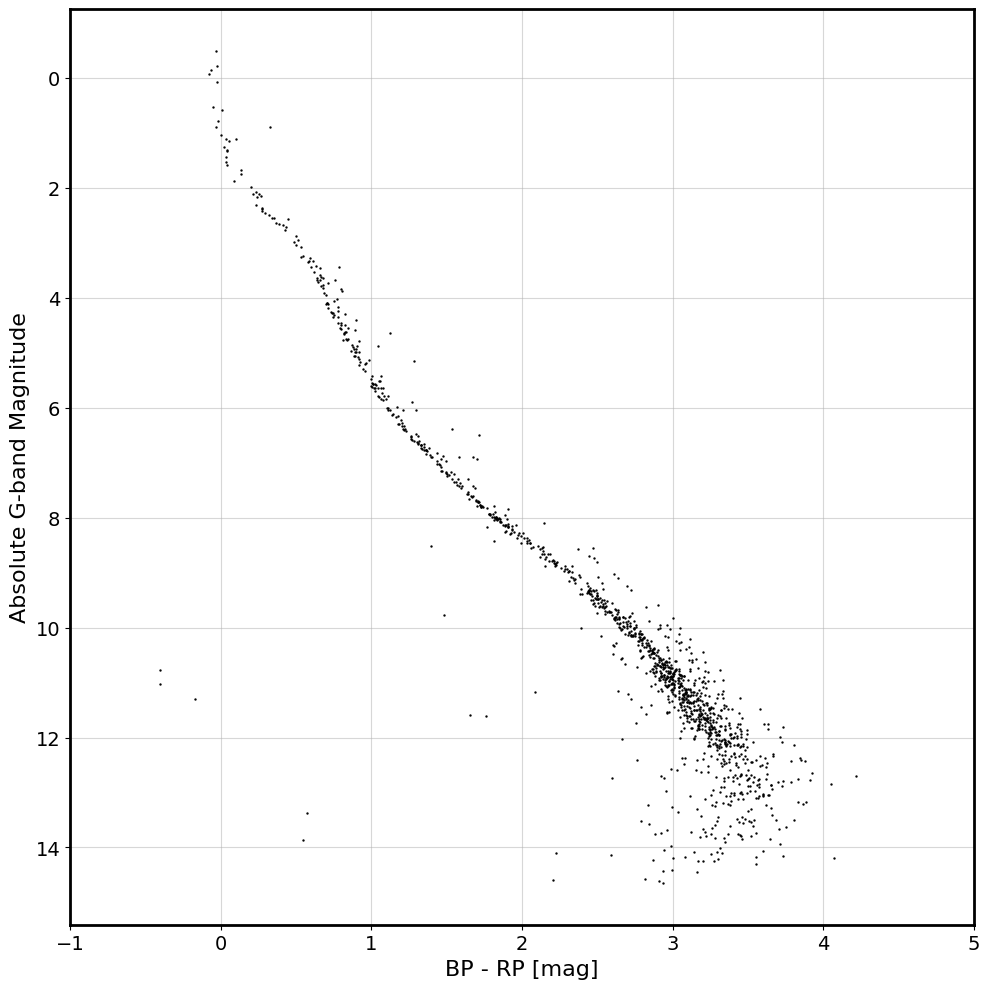

In [15]:
fig,ax = plt.subplots(figsize=(10, 10))
ax.scatter(data_table['bp_rp'][ple_cond],Mags[ple_cond],s=0.5,color='black',alpha=1,zorder=2)
# colors=['white','khaki','yellow','orange','red']
# for i in range(len(colors)):
#     ax.plot(mj0_bprp[i],mj0_mg[i],linestyle='none',marker='*',color=colors[i],markersize=14,markeredgecolor='black',markeredgewidth=0.7,label=spts_labels[i])

# #Set title, spines, ticks and ticklabels
ax.set_xlabel('BP - RP [mag]',fontsize=16)
ax.set_ylabel('Absolute G-band Magnitude',fontsize=16)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
# ax2 = ax.secondary_xaxis('top')
# ax2.set_xticks(mj0_bprp)
# ax2.set_xticklabels(spts_labels, rotation=0, fontsize=12)
# ax2.set_xlabel('Spectral Type',fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x',labelsize=14)
ax.invert_yaxis()
ax.set_xlim(-1,5)
ax.grid(alpha=0.5)

#ax.legend(loc='upper right',fontsize=14)
plt.tight_layout()
#plt.savefig('HW1_Figs\CAMDe.png',dpi=300)
plt.show()

In [16]:
from read_parsec_models import read_parsec_isochrones, save_isochrones_pickle, load_isochrones_pickle

b) Using MIST isochrones plot three isochrones (different ages) that reasonably fit the
color-magnitude diagram for the chemical composition of the cluster. Briefly describe the
other parameter inputs you used in generating the isochrones. Explain what you used to
judge whether an isochrone was a good fit or not. In your plot, include these points on your best-fit isochrone: i) the turnoff, ii) the base of
the giant branch (roughly where the isochrone makes a sharp turn upward), and iii) the
tip of the giant branch.

In [17]:
isochrones = read_parsec_isochrones('output375239433561.dat.txt')
#save_isochrones_pickle(isochrones, output_dir='.')

In [18]:
isochrones[0]['G_fSBmag'][-1]

-4.54

In [19]:
len(isochrones[0]['G_fSBmag'])

439

91.0 156
100.0 151
120.0 142


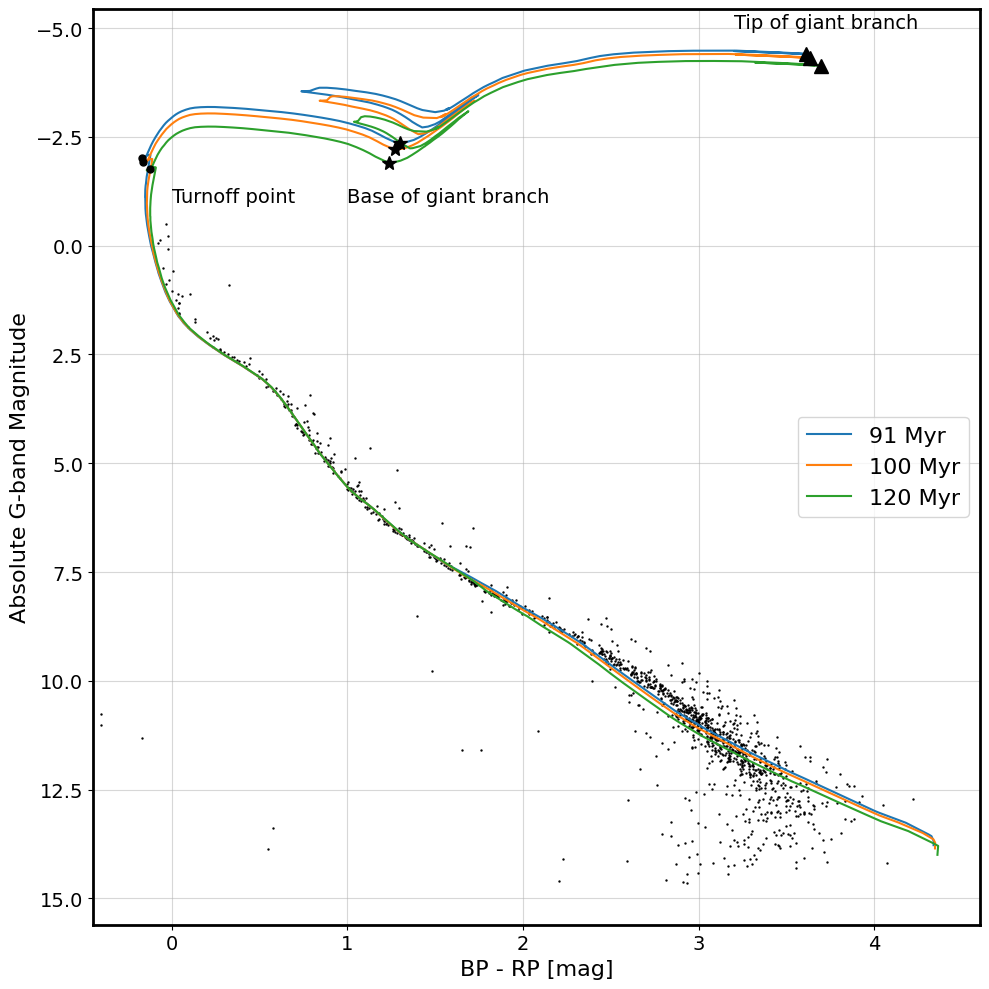

In [20]:
fig,ax = plt.subplots(figsize=(10, 10))
ax.scatter(data_table['bp_rp'][ple_cond],Mags[ple_cond],s=0.5,color='black',alpha=1,zorder=2)
turns_in = [156,151,142]
base_in = [202,195,188]
tip_in = [312,303,293]
i_mark=0
for i in range(len(isochrones)):
    age = np.round(isochrones[i]['age_Myr'])
    #ax.plot(isochrones[i]['G_BP_fSBmag'] - isochrones[i]['G_RP_fSBmag'],isochrones[i]['G_fSBmag'],label=f'{age:.0f} Myr')
    if age ==91 or age == 100 or age == 120:
        print(age,turns_in[i_mark])
        ax.plot(isochrones[i]['G_BP_fSBmag'] - isochrones[i]['G_RP_fSBmag'],isochrones[i]['G_fSBmag'],label=f'{age:.0f} Myr')
        ax.plot(isochrones[i]['G_BP_fSBmag'][turns_in[i_mark]] - isochrones[i]['G_RP_fSBmag'][turns_in[i_mark]],isochrones[i]['G_fSBmag'][turns_in[i_mark]],marker='.',markersize=10,zorder=4,color='black')
        ax.plot(isochrones[i]['G_BP_fSBmag'][base_in[i_mark]] - isochrones[i]['G_RP_fSBmag'][base_in[i_mark]],isochrones[i]['G_fSBmag'][base_in[i_mark]],marker='*',markersize=10,zorder=4,color='black')
        ax.plot(isochrones[i]['G_BP_fSBmag'][tip_in[i_mark]] - isochrones[i]['G_RP_fSBmag'][tip_in[i_mark]],isochrones[i]['G_fSBmag'][tip_in[i_mark]],marker='^',markersize=10,zorder=4,color='black')
        i_mark+=1
        #break

# #Set title, spines, ticks and ticklabels

ax.text(x=0,y=-1,s='Turnoff point',fontsize=14)
ax.text(x=1,y=-1,s='Base of giant branch',fontsize=14)
ax.text(x=3.2,y=-5,s='Tip of giant branch',fontsize=14)

ax.set_xlabel('BP - RP [mag]',fontsize=16)
ax.set_ylabel('Absolute G-band Magnitude',fontsize=16)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
# ax2 = ax.secondary_xaxis('top')
# ax2.set_xticks(mj0_bprp)
# ax2.set_xticklabels(spts_labels, rotation=0, fontsize=12)
# ax2.set_xlabel('Spectral Type',fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x',labelsize=14)
ax.invert_yaxis()
ax.set_xlim(-0.45)
#ax.set_ylim(16)
ax.grid(alpha=0.5)
ax.legend(fontsize=16)

#ax.legend(loc='upper right',fontsize=14)
plt.tight_layout()
plt.savefig('HW2_Figs/1b.png',dpi=300)
plt.show()

91.0 156
100.0 151
120.0 142


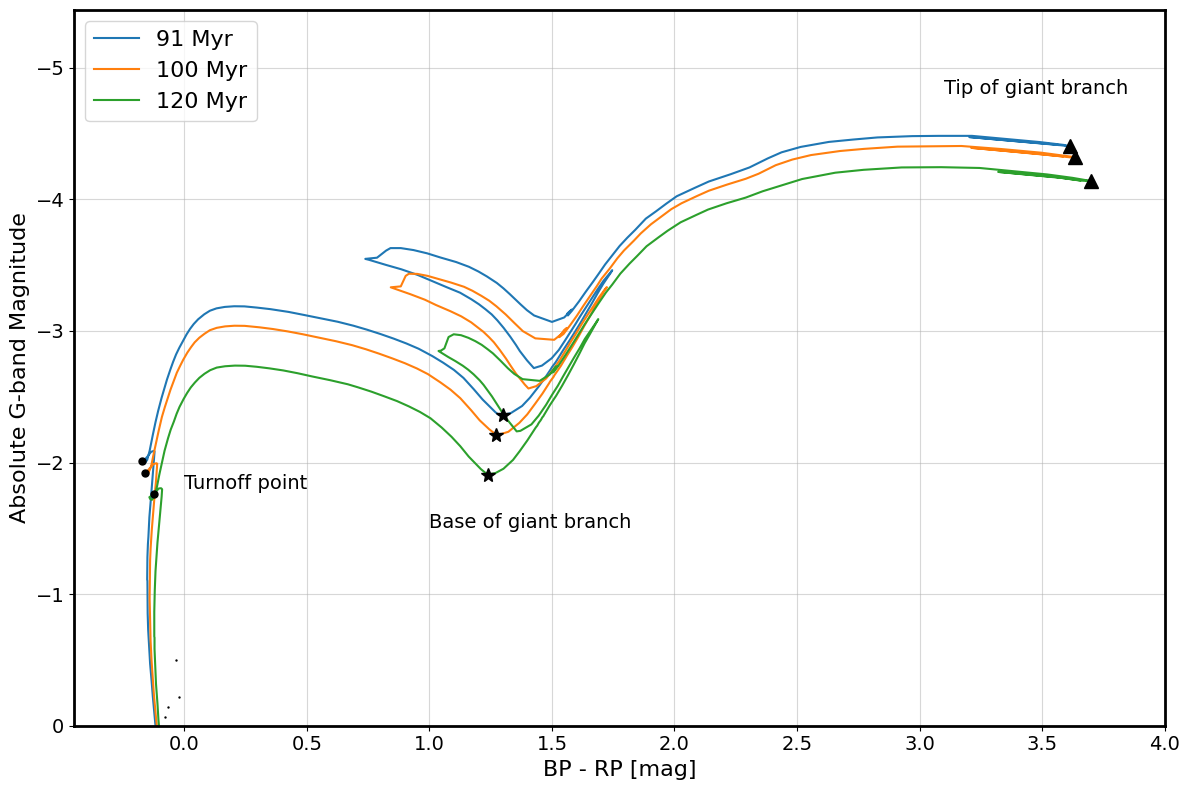

In [21]:
fig,ax = plt.subplots(figsize=(12, 8))
ax.scatter(data_table['bp_rp'][ple_cond],Mags[ple_cond],s=0.5,color='black',alpha=1,zorder=2)
turns_in = [156,151,142]
base_in = [202,195,188]
tip_in = [312,303,293]
i_mark=0
for i in range(len(isochrones)):
    age = np.round(isochrones[i]['age_Myr'])
    #ax.plot(isochrones[i]['G_BP_fSBmag'] - isochrones[i]['G_RP_fSBmag'],isochrones[i]['G_fSBmag'],label=f'{age:.0f} Myr')
    if age ==91 or age == 100 or age == 120:
        print(age,turns_in[i_mark])
        ax.plot(isochrones[i]['G_BP_fSBmag'] - isochrones[i]['G_RP_fSBmag'],isochrones[i]['G_fSBmag'],label=f'{age:.0f} Myr')
        ax.plot(isochrones[i]['G_BP_fSBmag'][turns_in[i_mark]] - isochrones[i]['G_RP_fSBmag'][turns_in[i_mark]],isochrones[i]['G_fSBmag'][turns_in[i_mark]],marker='.',markersize=10,zorder=4,color='black')
        ax.plot(isochrones[i]['G_BP_fSBmag'][base_in[i_mark]] - isochrones[i]['G_RP_fSBmag'][base_in[i_mark]],isochrones[i]['G_fSBmag'][base_in[i_mark]],marker='*',markersize=10,zorder=4,color='black')
        ax.plot(isochrones[i]['G_BP_fSBmag'][tip_in[i_mark]] - isochrones[i]['G_RP_fSBmag'][tip_in[i_mark]],isochrones[i]['G_fSBmag'][tip_in[i_mark]],marker='^',markersize=10,zorder=4,color='black')
        i_mark+=1
        #break

# #Set title, spines, ticks and ticklabels

ax.text(x=0,y=-1.8,s='Turnoff point',fontsize=14)
ax.text(x=1,y=-1.5,s='Base of giant branch',fontsize=14)
ax.text(x=3.1,y=-4.8,s='Tip of giant branch',fontsize=14)

ax.set_xlabel('BP - RP [mag]',fontsize=16)
ax.set_ylabel('Absolute G-band Magnitude',fontsize=16)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
# ax2 = ax.secondary_xaxis('top')
# ax2.set_xticks(mj0_bprp)
# ax2.set_xticklabels(spts_labels, rotation=0, fontsize=12)
# ax2.set_xlabel('Spectral Type',fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x',labelsize=14)
ax.invert_yaxis()
ax.set_xlim(-0.45,4)
ax.set_ylim(0)
ax.grid(alpha=0.5)
ax.legend(fontsize=16)

#ax.legend(loc='upper right',fontsize=14)
plt.tight_layout()
plt.savefig('HW2_Figs/1b_zoom.png',dpi=300)
plt.show()

c) Tabulate the masses, radii, and luminosities (in solar units) for stars at the three
evolution turning points from part b). Include a calculation of the gravitational (KelvinHelmholtz) and nuclear timescales. (For the post-main sequence stars, continue to assume
that 10% of the star’s mass is burned during a nuclear timescale.)

In [26]:
masses =[]
radii = []
lums = []
t_kh = []
t_nuc = []
i_mark=0
for i in range(len(isochrones)):
    age = np.round(isochrones[i]['age_Myr'])
    if age ==91 or age == 100 or age == 120:
        mass = isochrones[i]['Mass'][turns_in[i_mark]]
        lum = 10**(isochrones[i]['logL'][turns_in[i_mark]])
        temp = (10**isochrones[i]['logTe'][turns_in[i_mark]])/5778
        rad = temp**(-2) * (lum)**(1/2)
        tkh = (3 * 10**7) *(mass**2) * (rad**(-1)) * (lum**(-1))
        tnuc = (0.007 * 0.1 * mass * 10**10) / lum
        masses.append(mass)
        radii.append(rad)
        lums.append(lum)
        t_kh.append(tkh)
        t_nuc.append(tnuc)
        i_mark+=1
tab_turn = Table([masses, radii,lums,t_kh,t_nuc], names=('Masses', 'Radii', 'Luminosities','t_kh','t_nuc'))
for col in tab_turn.colnames:
    tab_turn[col].format = '.2f'
print(tab_turn)

Masses Radii Luminosities    t_kh    t_nuc  
------ ----- ------------ --------- --------
  5.20  5.80      1713.96  81634.52 21249.65
  5.00  5.69      1489.36  88695.34 23518.81
  4.63  5.77      1023.29 109019.27 31685.94


d) Generate a MIST evolution track for the mass of the turnoff star. Compare the age of
the star at the turnoff to the nuclear timescale.
Compare the time it would take the turnoff star to reach the tip of the giant branch to the
gravitational timescale. What percentage of the cluster age would this evolution take?

In [1]:
import read_mist_models

In [2]:
eep = read_mist_models.EEP(r'MIST_eep_698da4f335610\0050000M.track.eep')

Reading in: MIST_eep_698da4f335610\0050000M.track.eep


1390
117106603.96213844
Age at in 500: 100500921.1525475 100.50092115254749
Age at in 1000: 117089143.95514743 117.08914395514742
Age at turn-off = 117107998.95 yrs, 117.11 Myr
Age diff at tip - turn-off = -1394.9890 yrs, -0.0014 Myr


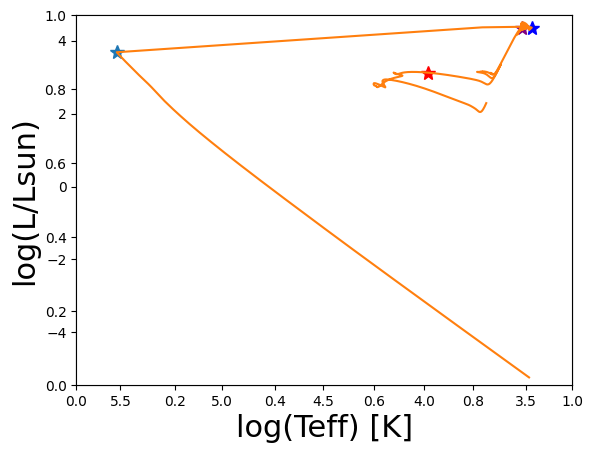

In [3]:
eep.plot_HR()

In [4]:
117107998.95109893 * 1e-6

117.10799895109893

### 2 - Spectral Types

a) Obtain a spectrum for an A star, and two others of different spectral type in luminosity
class V. Be sure to choose near-solar metallicity stars. Tabulate the ID, Teff, log g, and
[Fe/H] for the stars you choose. Plot each spectrum and identify (on the plot) the major spectral lines that are used to
distinguish between spectral types. (Pay attention to lines that drop more than 25%
below the continuum surrounding the line.) When a line is visible in more than one of the
spectra, comment on the relative strengths of the lines and the physical reasons behind
the differences.

In [123]:
spec_name = r'XSL_DR3_release\XSL_DR3_release\xsl_spectrum_X0358_merged.fits'
[flux_temp, flux_tempdr_temp, waves_temp, unit, star, loss_corr, Av, Av_ori]= read_dr3_spec(spec_name, ang='on', star_kw='on', loss_corr_kw='on', av_kw = 'on')

 
File to read: XSL_DR3_release\XSL_DR3_release\xsl_spectrum_X0358_merged.fits


In [10]:
flux_temp

array([1.0093689e-12, 1.0136595e-12, 1.0308501e-12, ..., 2.6845659e-14,
       2.5148771e-14, 2.4558031e-14], dtype='>f4')

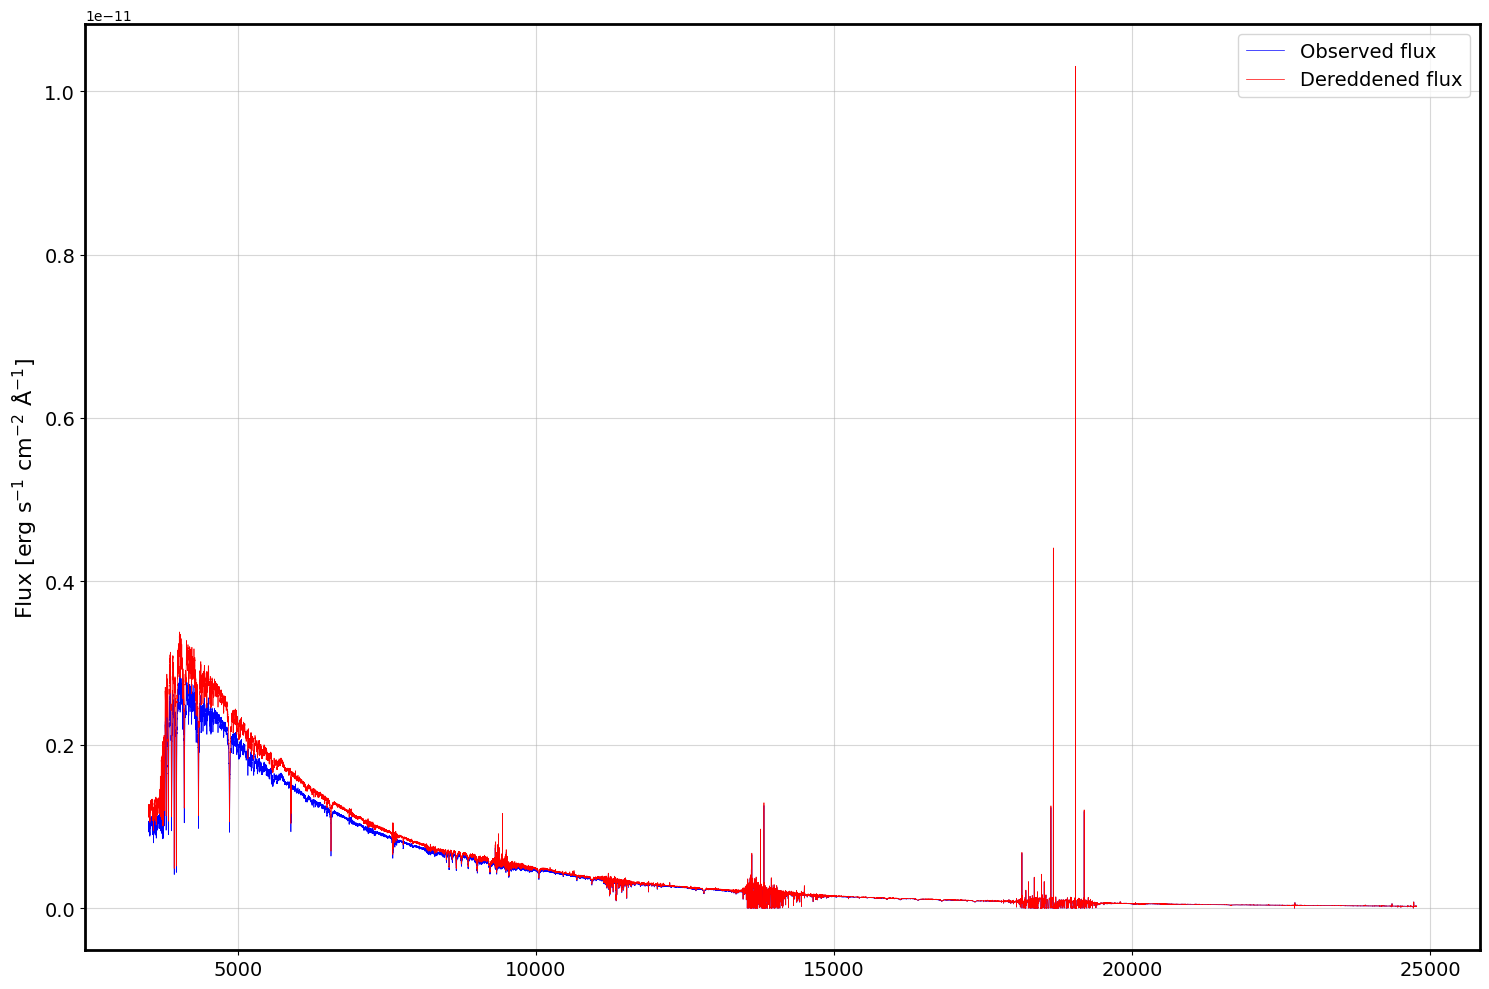

In [124]:
fig,ax = plt.subplots(figsize=(15, 10))
#plt.plot(waves_temp, flux_temp, linewidth=0.5, label='Observed flux')
plt.plot(waves_temp, flux_temp, 'b-', linewidth=0.5, label='Observed flux')
if not np.all(np.isnan(flux_tempdr_temp)):
   plt.plot(waves_temp, flux_tempdr_temp, 'r-', linewidth=0.5, label='Dereddened flux')
# plt.xlabel(f'Wavelength [Å]',fontsize=16)
plt.ylabel('Flux [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]',fontsize=16)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x',labelsize=14)
ax.grid(alpha=0.5)

ax.legend(loc='upper right',fontsize=14)
plt.tight_layout()
#plt.savefig('HW1_Figs\CAMDe.png',dpi=300)
plt.show()

b) Looking at the log g-Teff diagram (a kind of spectroscopic HR diagram) for the sample,
discuss the number of library stars in each of the following ranges, and under what circum-
stances they would be important for population modelling and/or automatic classification,
in a paragraph each:
• 10000 K < Teff < 40000 K, 3 < log g < 4
• 5000 K < Teff < 10000 K, 3.5 < log g < 4.5
• 3000 K < Teff < 5000 K, 4.5 < log g < 5.5
• 3000 K < Teff < 6000 K, 0 < log g < 3

c) For the A0 and one other star, integrate the spectrum in the B and V filter ranges,
and find the ratio FB/FV for each. If an A0 star is defined to have a color B − V = 0,
determine the color of the other star.

d) For one spectrum with a noticeable optical Hβ line, “normalize” the spectrum by fitting
the continuum and setting that to 1. Plot the normalized spectrum around the Hβ line,
and compute the equivalent width.

e) Obtain a theoretical flux distribution from the ATLAS9 repository for the characteristics of one of your non-A0 stars. Provide a plot of the comparison with the XSL data, and
give the Teff and log g values you used. Describe briefly how you normalized the model to
the data, and comment on the degree of agreement between the two.